## **Proyecto Final - Enfermedad Hepática (ILPD)**

Made by: John Fredy Beltran Cuellar y Santiago Trejos
Date: 11/04/2025
Goal: Desarrollar y evaluar un modelo de clasificación basado en técnicas de Machine Learning para predecir la presencia de enfermedad hepática en pacientes, utilizando el dataset ILPD, con el fin de apoyar el proceso de diagnóstico clínico y contribuir a la toma de decisiones en el ámbito de la salud.


In [115]:
#step 0. load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
from xgboost import XGBClassifier
from collections import Counter


In [100]:
# step 1. load data
# Carga y rename
df_raw = pd.read_csv("/workspaces/projecto_final_clasificacion_ILPD/Indian Liver Patient Dataset (ILPD).csv")
df_raw.columns = ["Age","Gender","TB","DB","Alkphos","Sgpt","Sgot","TP","ALB","A/G Ratio","Target"]



Tabla 1. Diccionario de Variables del Dataset ILPD
| Nombre del Campo | Nombre Completo | Descripción | Unidades / Valores |
|---|---|---|---|
| **Age** | Edad del Paciente | Edad del paciente en años | Años |
| **Gender** | Género | Sexo biológico del paciente | Male / Female |
| **TB** | Total Bilirubin | Nivel total de bilirrubina en sangre | mg/dL |
| **DB** | Direct Bilirubin | Bilirrubina conjugada; elevada indica daño hepático | mg/dL |
| **Alkphos** | Alkaline Phosphatase | Enzima asociada a obstrucción biliar o daño hepático | IU/L |
| **Sgpt** | ALT — Alanine Aminotransferase | Enzima hepática, elevada en daño hepático | IU/L |
| **Sgot** | AST — Aspartate Aminotransferase | Enzima hepática, elevada en inflamación hepática o daño muscular | IU/L |
| **TP** | Total Proteins | Cantidad total de proteínas en sangre | g/dL |
| **ALB** | Albumin | Proteína producida por el hígado; baja indica fallo hepático | g/dL |
| **A/G Ratio** | Albumin/Globulin Ratio | Relación albúmina–globulina; baja en enfermedad hepática | Razón |
| **Liver Disease** | Indicador de Enfermedad Hepática | Indica si el paciente tiene enfermedad hepática | 1 = Enfermo / 0 = Sano |

In [101]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        582 non-null    int64  
 1   Gender     582 non-null    object 
 2   TB         582 non-null    float64
 3   DB         582 non-null    float64
 4   Alkphos    582 non-null    int64  
 5   Sgpt       582 non-null    int64  
 6   Sgot       582 non-null    int64  
 7   TP         582 non-null    float64
 8   ALB        582 non-null    float64
 9   A/G Ratio  578 non-null    float64
 10  Target     582 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.1+ KB


In [102]:
df_raw.sample(10)

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
332,36,Female,0.7,0.2,152,21,25,5.9,3.1,1.1,2
535,46,Male,15.8,7.2,227,67,220,6.9,2.6,0.6,1
238,40,Male,0.9,0.3,196,69,48,6.8,3.1,0.8,1
96,39,Male,6.6,3.0,215,190,950,4.0,1.7,0.7,1
15,38,Male,1.8,0.8,342,168,441,7.6,4.4,1.3,1
208,45,Female,0.9,0.3,189,23,33,6.6,3.9,NaN,1
157,72,Male,0.7,0.1,196,20,35,5.8,2.0,0.5,1
18,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
138,15,Male,0.8,0.2,380,25,66,6.1,3.7,1.5,1
167,60,Male,22.8,12.6,962,53,41,6.9,3.3,0.9,1


In [103]:
# step 2. preprecessing
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.lower().str.replace(" ", "_").str.replace("/", "_")
df_baking['gender'] = df_baking['gender'].astype('category')
df_baking['a_g_ratio'].fillna(df_baking['a_g_ratio'].median(), inplace=True)
df_baking.isna().sum()
df = df_baking.copy()

/tmp/ipykernel_8329/2691822281.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_baking['a_g_ratio'].fillna(df_baking['a_g_ratio'].median(), inplace=True)


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        582 non-null    int64   
 1   gender     582 non-null    category
 2   tb         582 non-null    float64 
 3   db         582 non-null    float64 
 4   alkphos    582 non-null    int64   
 5   sgpt       582 non-null    int64   
 6   sgot       582 non-null    int64   
 7   tp         582 non-null    float64 
 8   alb        582 non-null    float64 
 9   a_g_ratio  582 non-null    float64 
 10  target     582 non-null    int64   
dtypes: category(1), float64(5), int64(5)
memory usage: 46.3 KB


In [105]:
# step 3. EDA
# Dividimos en train/test
df_train, df_test = train_test_split(df, test_size=0.2,stratify=df['target'], random_state=2025)

# dividimos train en train/validation
df_train, df_val = train_test_split(df_train, test_size=0.15, random_state=2025)

# Resetear índices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_test.shape, df_val.shape


((395, 11), (117, 11), (70, 11))

In [106]:
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)


,count,mean,std,min,25%,50%,75%,max
age,395.0,45.027848,16.459972,4.0,32.500,46.00,58.0,90.0
tb,395.0,3.364810,6.404286,0.4,0.800,1.00,2.7,75.0
db,395.0,1.502532,2.756845,0.1,0.200,0.30,1.3,18.3
alkphos,395.0,291.840506,250.985565,63.0,175.000,208.00,298.0,2110.0
sgpt,395.0,85.650633,193.532417,10.0,24.000,36.00,61.5,2000.0
sgot,395.0,120.501266,329.273022,10.0,25.000,43.00,93.5,4929.0
tp,395.0,6.452405,1.063450,2.7,5.700,6.50,7.1,9.5
alb,395.0,3.119494,0.784009,0.9,2.600,3.10,3.7,5.5
a_g_ratio,395.0,0.950658,0.320453,0.3,0.705,0.95,1.1,2.8
target,395.0,1.283544,0.451290,1.0,1.000,1.00,2.0,2.0


,count,unique,top,freq
gender,395,2,Male,302


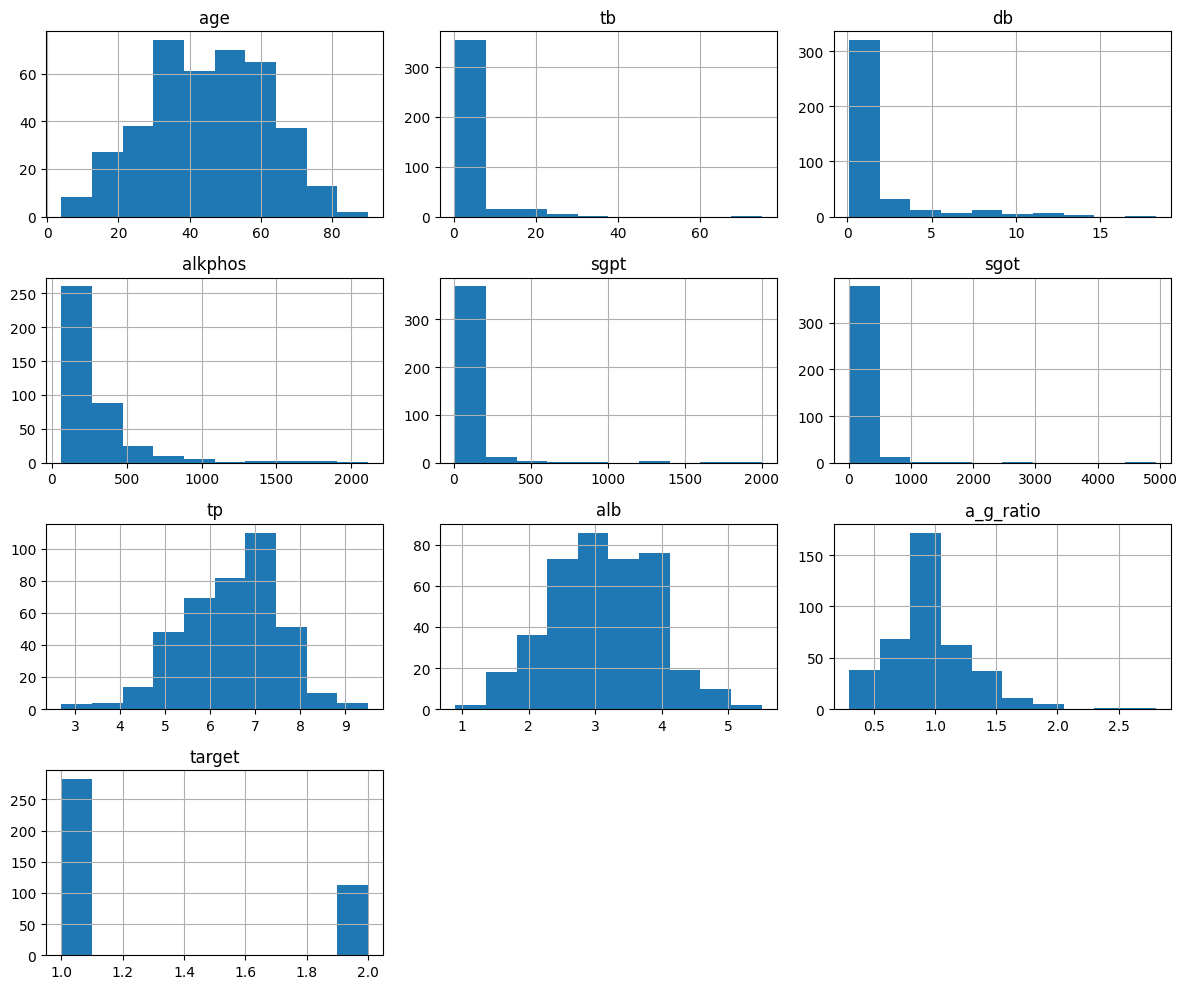

In [107]:
df_train.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

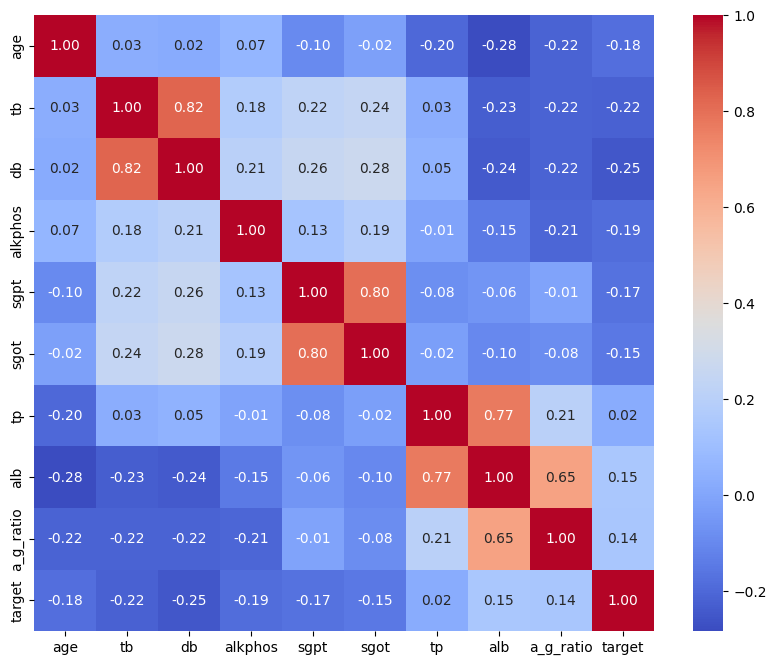

In [108]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

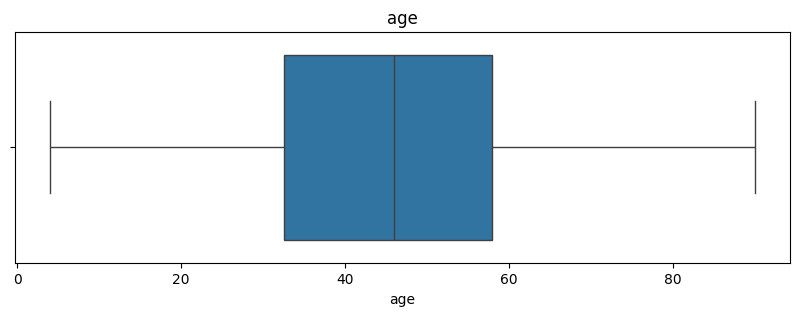

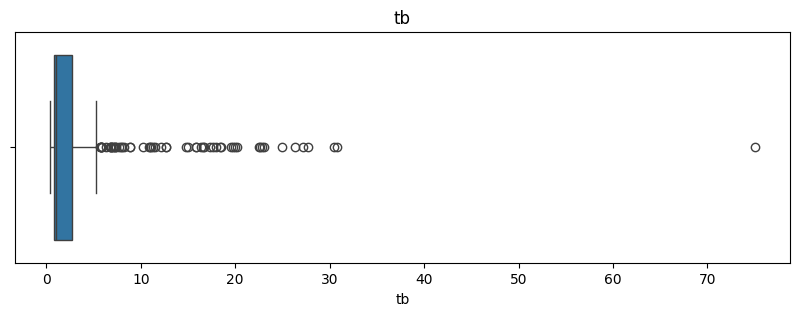

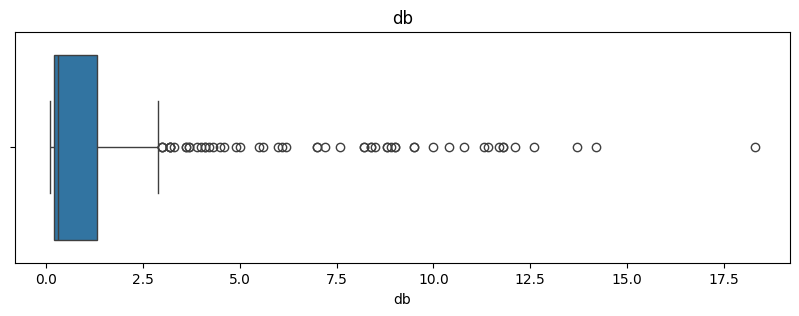

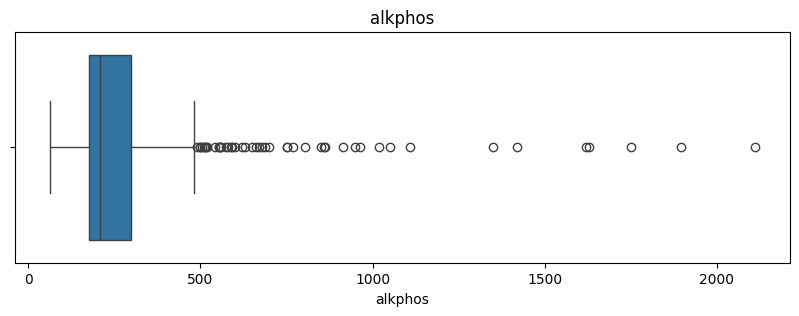

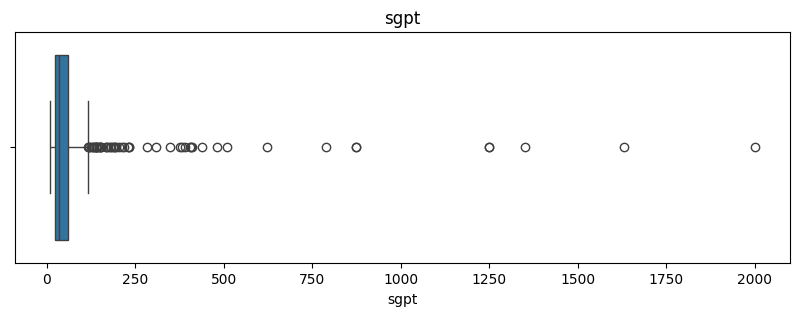

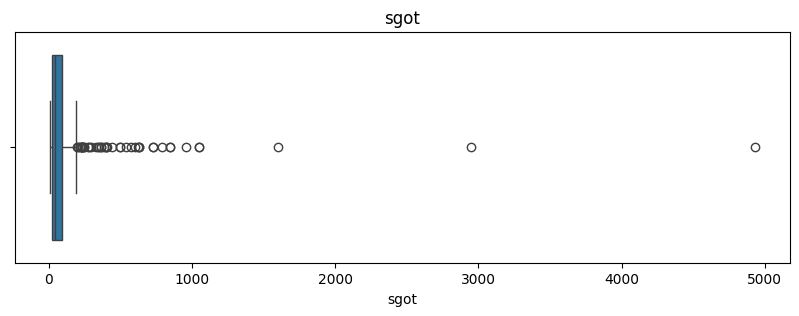

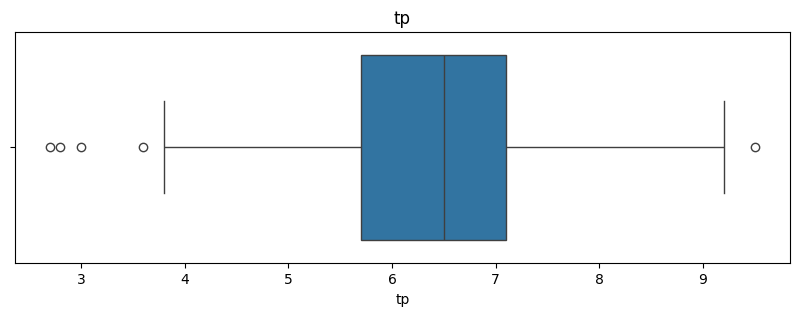

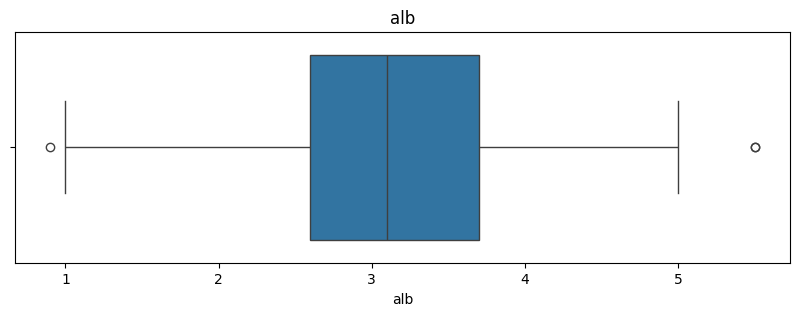

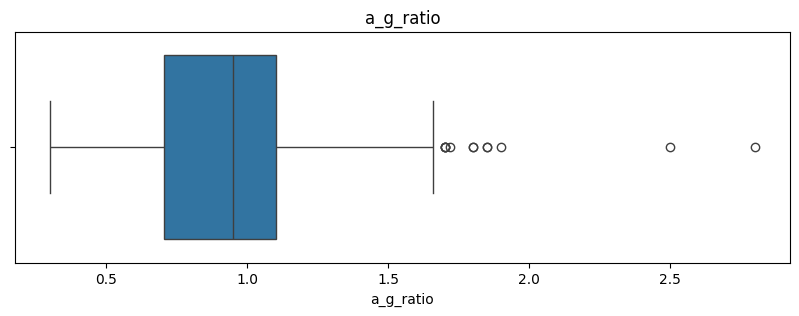

In [109]:
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols.remove('target')  # quitamos la variable target

for col in numeric_cols:
    plt.figure(figsize=(10,3))
    sns.boxplot(x=df_train[col])
    plt.title(col)
    plt.show()

In [110]:
# step 4. ML
# Separar X e y
X_train = df_train.drop('target', axis=1)
y_train = df_train['target']
X_val = df_val.drop('target', axis=1)
y_val = df_val['target']
X_test = df_test.drop('target', axis=1)
y_test = df_test['target']




In [111]:
# Codificar etiquetas a 0,1,...n
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [112]:
# Columnas numéricas y categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [118]:
# Pipeline completo (clasificación)

counter = Counter(y_train_enc)
scale_pos_weight = counter[0] / counter[1]  # mayoritaria / minoritaria

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=2025,
        use_label_encoder=False,
        eval_metric='logloss', # evita warnings
        scale_pos_weight=scale_pos_weight
    ))
])
pipeline.fit(X_train, y_train_enc)

/workspaces/projecto_final_clasificacion_ILPD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [03:24:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [119]:


y_pred_val = pipeline.predict(X_val)
y_pred_test = pipeline.predict(X_test)

def evaluar(y_true_enc, y_pred_enc, dataset_name="Dataset"):
    y_true = le.inverse_transform(y_true_enc)
    y_pred = le.inverse_transform(y_pred_enc)
    print(f"==== {dataset_name} ====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_true, y_pred, average='weighted'))
    print("Matriz de confusión:\n", confusion_matrix(y_true, y_pred))
    print("\n")
evaluar(y_val_enc, y_pred_val, "Validation")
evaluar(y_test_enc, y_pred_test, "Test")

==== Validation ====
Accuracy: 0.6142857142857143
Precision: 0.6403846153846154
Recall: 0.6142857142857143
F1-score: 0.6244337680164722
Matriz de confusión:
 [[33 16]
 [11 10]]


==== Test ====
Accuracy: 0.6752136752136753
Precision: 0.680911680911681
Recall: 0.6752136752136753
F1-score: 0.6778730754340511
Matriz de confusión:
 [[63 20]
 [18 16]]


